In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from koala import graph_utils as gu
from koala import plotting as pl
from simulation import solve_lattice_data

from dimer_models.kasteleyn import generate_kasteleyn_orientation
from dimer_models.lattice_generation import bipartite_squarefull


Make a random lattice

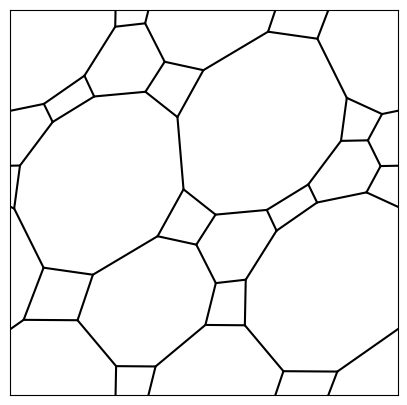

In [3]:
size = 40

# if no lattice exists, make one
try:
    lattice
except NameError:
    rng = np.random.default_rng()
    lattice = bipartite_squarefull(size)
    lattice = gu.tutte_embedding(lattice)

fig, ax = plt.subplots(figsize=(5, 5))
pl.plot_edges(lattice)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [4]:
n_pairs = 10
edge_list = np.array([rng.choice(lattice.n_edges, 2, replace=False) for _ in range(n_pairs)])
plaq_list = np.array([rng.choice(lattice.n_plaquettes, 2, replace=False) for _ in range(n_pairs)])


First we calculate all the quantities with brute force

In [5]:
def dimer_dimer_prob(dimerisations, chosen_edges):
    e = np.array([dimerisations[:, x] for x in chosen_edges])
    return np.average(e.prod(axis=0))


# brute force dimerisations
brute_dimerisations = gu.dimerise(lattice, -1)
brute_dimer_probabilities = np.average(brute_dimerisations, axis=0)
brute_dimer_dimer_probabilities = np.array(
    [dimer_dimer_prob(brute_dimerisations, c) for c in edge_list]
)
brute_n_dimerisations = brute_dimerisations.shape[0]

# brute force visons
brute_force_visons = []
initial_ujk = generate_kasteleyn_orientation(lattice)
for p in plaq_list:
    monomer_ujk = generate_kasteleyn_orientation(lattice, p, initial_ujk)
    flip_edges = np.where(monomer_ujk - initial_ujk)[0]
    sign = np.prod((-1) ** brute_dimerisations[:, flip_edges], axis=1)
    brute_force_visons.append(abs(np.sum(sign)))
brute_force_visons = np.array(brute_force_visons)


Then we calculate them using the fancy kasteleyn methods

In [ ]:
res = solve_lattice_data(lattice, edge_list, plaq_list)
n_dimerisations = res["n_dimerisations"]
edge_probabilities = res["edge_probabilities"]
multi_probabilities = res["multi_probabilities"]
visons = res["visons"]
monomers = res["monomers"]


Finally, make sure both give the same results

In [7]:
# all the checks
# print(monomers)
assert n_dimerisations == brute_n_dimerisations
assert np.allclose(edge_probabilities, brute_dimer_probabilities)
assert np.allclose(brute_dimer_dimer_probabilities, multi_probabilities)
assert np.allclose(brute_force_visons, visons)

for key in monomers:
    reduced_lattice = gu.remove_vertices(lattice, np.array(key))
    nn = gu.dimerise(reduced_lattice, -1).shape[0]
    assert monomers[key] == nn

If nothing went wrong, delete the lattice for the next round

In [8]:
del lattice